In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Palo Alto Networks.csv to Palo Alto Networks.csv


In [ ]:
df = pd.read_csv('Palo Alto Networks.csv')

In [ ]:
df.shape

(1470, 31)

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
0,83.877551
1,16.122449


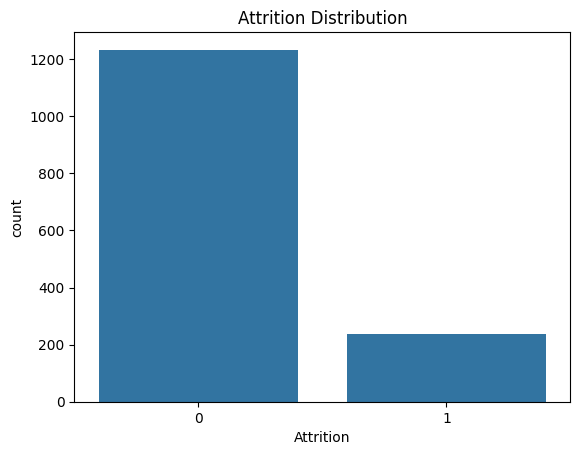

In [ ]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

In [ ]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

In [ ]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
26-35,606
36-45,468
46-55,226
18-25,115
56-65,47


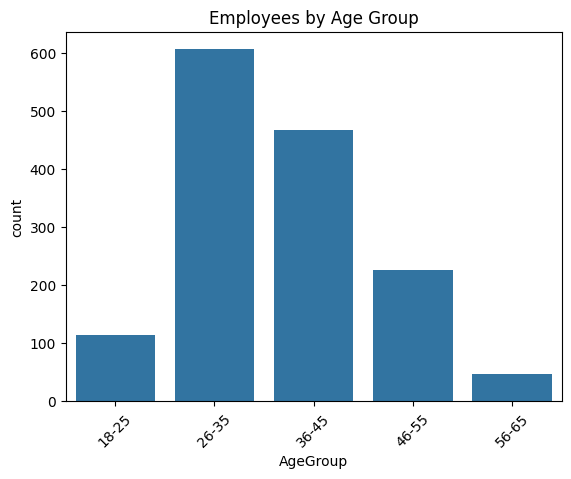

In [ ]:
sns.countplot(x='AgeGroup', data=df)
plt.title("Employees by Age Group")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0,2,5,10,40],
    labels=['0-2 Years','3-5 Years','6-10 Years','10+ Years']
)

In [ ]:
df['TenureGroup'].value_counts()

,count
TenureGroup,
6-10 Years,448
3-5 Years,434
0-2 Years,298
10+ Years,246


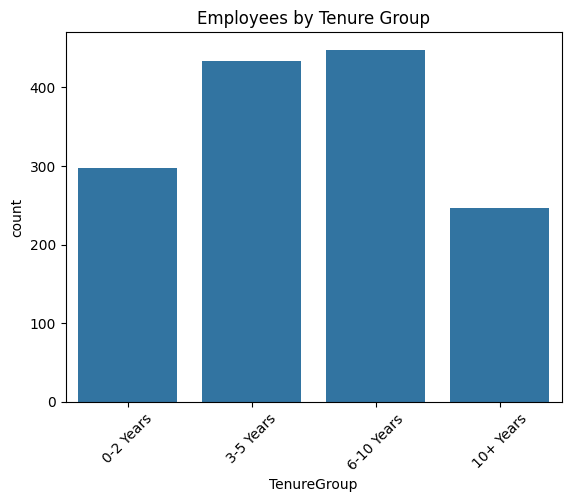

In [ ]:
sns.countplot(x='TenureGroup', data=df)
plt.title("Employees by Tenure Group")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['DistanceGroup'] = pd.cut(
    df['DistanceFromHome'],
    bins=[0,5,10,20,30],
    labels=['0-5 KM','6-10 KM','11-20 KM','21-30 KM']
)

In [ ]:
df['DistanceGroup'].value_counts()

,count
DistanceGroup,
0-5 KM,632
6-10 KM,394
11-20 KM,240
21-30 KM,204


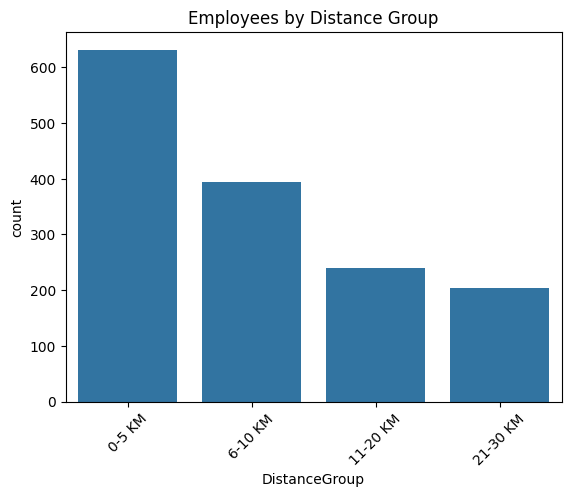

In [ ]:
sns.countplot(x='DistanceGroup', data=df)
plt.title("Employees by Distance Group")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df[['AgeGroup','TenureGroup','DistanceGroup']].head()

,AgeGroup,TenureGroup,DistanceGroup
0,36-45,6-10 Years,0-5 KM
1,46-55,6-10 Years,6-10 KM
2,36-45,NaN,0-5 KM
3,26-35,6-10 Years,0-5 KM
4,26-35,0-2 Years,0-5 KM


In [ ]:
age_attrition = pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
) * 100

print(age_attrition.round(2))

Attrition      0      1
AgeGroup               
18-25      65.22  34.78
26-35      80.86  19.14
36-45      90.81   9.19
46-55      88.50  11.50
56-65      82.98  17.02


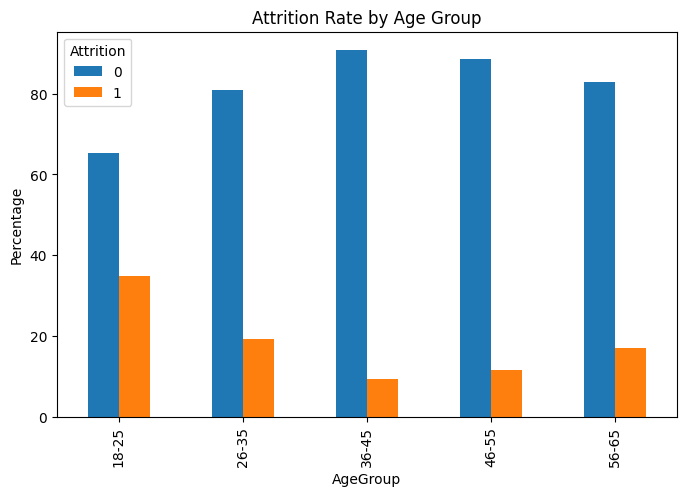

In [ ]:
age_attrition.plot(kind='bar', figsize=(8,5))
plt.title("Attrition Rate by Age Group")
plt.ylabel("Percentage")
plt.show()

In [ ]:
tenure_attrition = pd.crosstab(
    df['TenureGroup'],
    df['Attrition'],
    normalize='index'
) * 100

print(tenure_attrition.round(2))

Attrition        0      1
TenureGroup              
0-2 Years    71.14  28.86
3-5 Years    86.18  13.82
6-10 Years   87.72  12.28
10+ Years    91.87   8.13


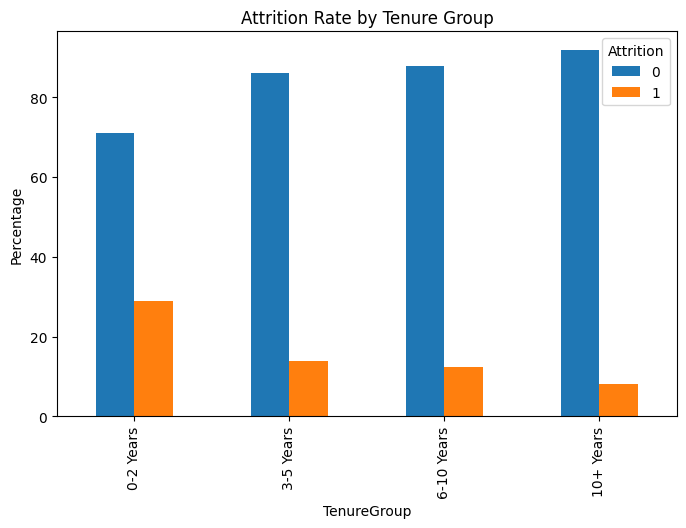

In [ ]:
tenure_attrition.plot(kind='bar', figsize=(8,5))
plt.title("Attrition Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

In [ ]:
distance_attrition = pd.crosstab(
    df['DistanceGroup'],
    df['Attrition'],
    normalize='index'
) * 100

print(distance_attrition.round(2))

Attrition          0      1
DistanceGroup              
0-5 KM         86.23  13.77
6-10 KM        85.53  14.47
11-20 KM       80.00  20.00
21-30 KM       77.94  22.06


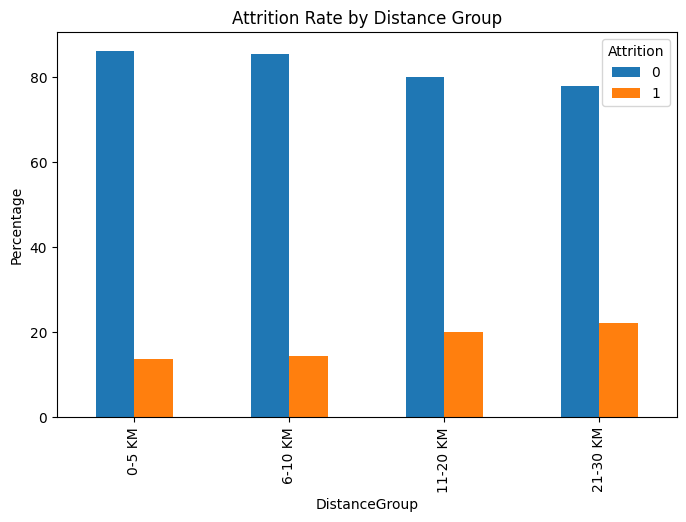

In [ ]:
distance_attrition.plot(kind='bar', figsize=(8,5))
plt.title("Attrition Rate by Distance Group")
plt.ylabel("Percentage")
plt.show()

In [ ]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

print(dept_attrition.round(2))

Attrition                   0      1
Department                          
Human Resources         80.95  19.05
Research & Development  86.16  13.84
Sales                   79.37  20.63


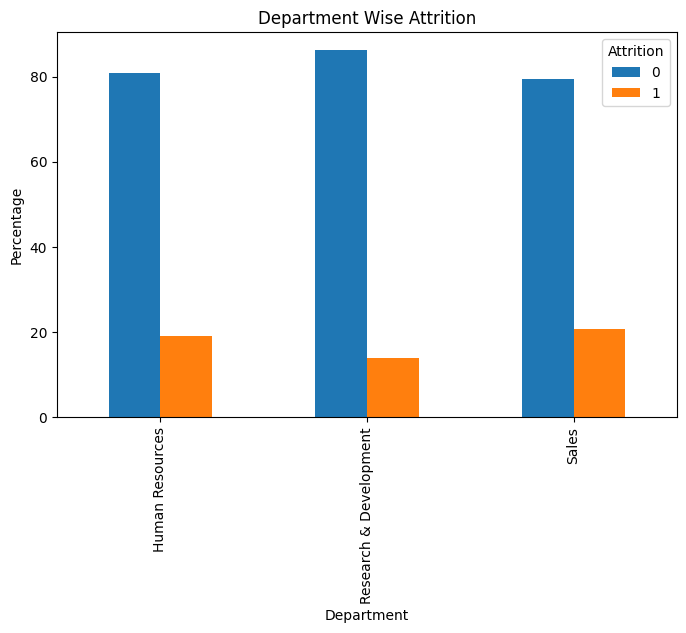

In [ ]:
dept_attrition.plot(kind='bar', figsize=(8,5))
plt.title("Department Wise Attrition")
plt.ylabel("Percentage")
plt.show()

In [ ]:
role_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

print(role_attrition.round(2))

Attrition                      0      1
JobRole                                
Healthcare Representative  93.13   6.87
Human Resources            76.92  23.08
Laboratory Technician      76.06  23.94
Manager                    95.10   4.90
Manufacturing Director     93.10   6.90
Research Director          97.50   2.50
Research Scientist         83.90  16.10
Sales Executive            82.52  17.48
Sales Representative       60.24  39.76


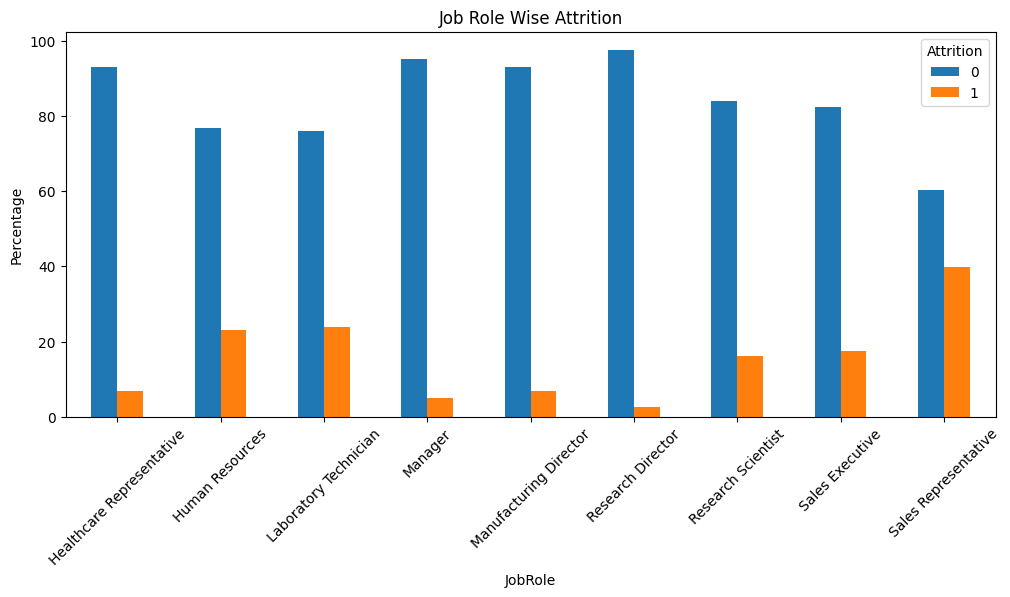

In [ ]:
role_attrition.plot(kind='bar', figsize=(12,5))
plt.title("Job Role Wise Attrition")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [ ]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

print(overtime_attrition.round(2))

Attrition      0      1
OverTime               
No         89.56  10.44
Yes        69.47  30.53


In [ ]:
travel_attrition = pd.crosstab(
    df['BusinessTravel'],
    df['Attrition'],
    normalize='index'
) * 100

print(travel_attrition.round(2))

Attrition              0      1
BusinessTravel                 
Non-Travel         92.00   8.00
Travel_Frequently  75.09  24.91
Travel_Rarely      85.04  14.96


In [ ]:
gender_attrition = pd.crosstab(
    df['Gender'],
    df['Attrition'],
    normalize='index'
) * 100

print(gender_attrition.round(2))

Attrition      0      1
Gender                 
Female     85.20  14.80
Male       82.99  17.01


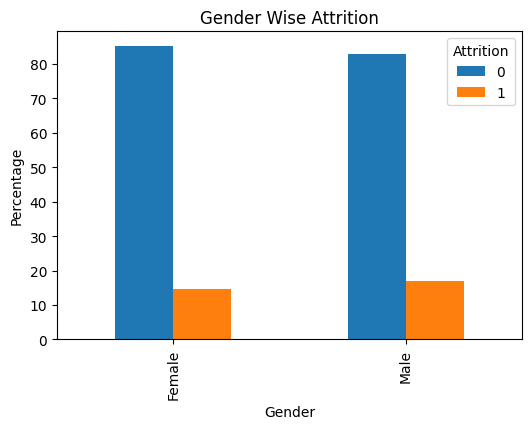

In [ ]:
gender_attrition.plot(kind='bar', figsize=(6,4))
plt.title("Gender Wise Attrition")
plt.ylabel("Percentage")
plt.show()

In [ ]:
marital_attrition = pd.crosstab(
    df['MaritalStatus'],
    df['Attrition'],
    normalize='index'
) * 100

print(marital_attrition.round(2))

Attrition          0      1
MaritalStatus              
Divorced       89.91  10.09
Married        87.52  12.48
Single         74.47  25.53


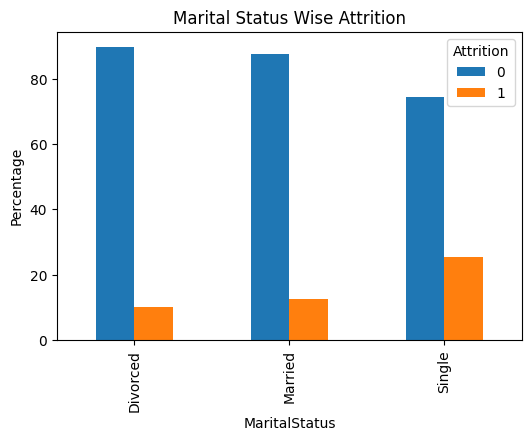

In [ ]:
marital_attrition.plot(kind='bar', figsize=(6,4))
plt.title("Marital Status Wise Attrition")
plt.ylabel("Percentage")
plt.show()

In [ ]:
education_attrition = pd.crosstab(
    df['EducationField'],
    df['Attrition'],
    normalize='index'
) * 100

print(education_attrition.round(2))

Attrition             0      1
EducationField                
Human Resources   74.07  25.93
Life Sciences     85.31  14.69
Marketing         77.99  22.01
Medical           86.42  13.58
Other             86.59  13.41
Technical Degree  75.76  24.24


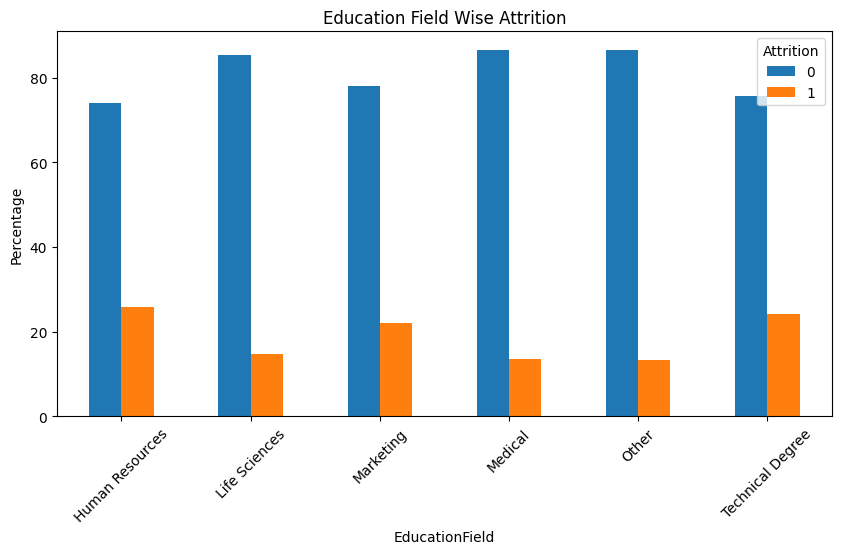

In [ ]:
education_attrition.plot(kind='bar', figsize=(10,5))
plt.title("Education Field Wise Attrition")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv('Palo_Alto_Cleaned.csv', index=False)

In [ ]:
from google.colab import files

files.download('Palo_Alto_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>